In [1]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy.stats import spearmanr

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from collections import Counter

import Geometry

from IPython.display import display, clear_output

In [2]:
from __future__ import print_function
import warnings
warnings.filterwarnings('ignore') # make the notebook nicer


# import os
# os.environ['QT_QPA_PLATFORM']='offscreen'

import nglview as nv
import pytraj as pt

print("nglview version = {}".format(nv.__version__))
print("pytraj version = {}".format(pt.__version__))

from Bio.PDB import PDBParser, Select, PDBIO, Polypeptide
from Bio.SeqUtils import seq1

nglview version = 3.1.1
pytraj version = 2.0.6


In [3]:
import IPython

In [4]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [9]:
from utils import read_pfam_table_pandas

In [ ]:
from adk_drawer import get_guiding_structures, ss_to_domains, draw_adk

ss_cmap = {'H':'red', 'E':'blue', 'L':'gray'}
domain_cmap = {'core':'red', 'lid':'blue', 'nmp':'green', 'none':'gray', 'ploop':'yellow'}
nglview_list = lambda cmap, residue_ss: [[cmap[r], str(i)] for i, r in enumerate(residue_ss)]

## Reference code

```
# make a list of references
~/fiererlab/adenylate_kinase_ogt/data/pdb$ cat *.faa > all_pdb_adk_chains.faa
# search references for lid
cd ~/fiererlab/adenylate_kinase_ogt/data/PF05191
hmmsearch --tblout ~/fiererlab/adenylate_kinase_ogt/data/foldseek/db/lidless_ref_adks.txt PF05191.hmm ./../pdb/all_pdb_adk_chains.faa
```

In [11]:
refs = read_pfam_table_pandas('~/fiererlab/adenylate_kinase_ogt/data/foldseek/db/lidless_ref_adks.txt')
refs['id'] = refs['target_name'].apply(lambda x: x.split('_chain')[0])

In [19]:
all_ids = [s.split('/')[-1].split('_A')[0] for s in glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/pdb/*_A.pdb')]

In [24]:
reference_scores = refs.groupby('id').apply(lambda x: x.sort_values('full_score').iloc[0, :])['full_score'].reindex(all_ids)

<Axes: xlabel='full_score', ylabel='Count'>

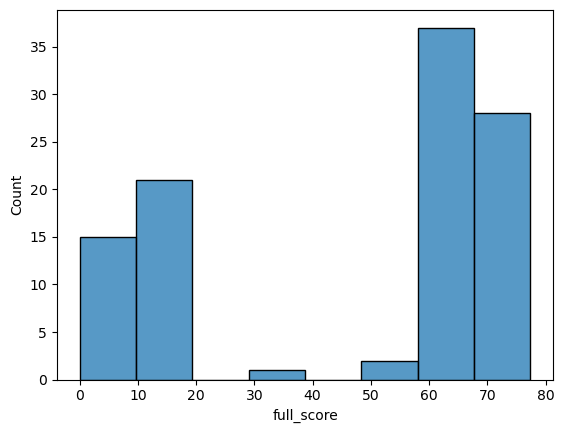

In [25]:
sns.histplot(reference_scores.fillna(0))

In [26]:
reference_scores[reference_scores.isnull()]

id
4w5h   NaN
2cdn   NaN
3cm0   NaN
1p4s   NaN
2h92   NaN
2cmk   NaN
1kdo   NaN
1kdp   NaN
1kdr   NaN
1kdt   NaN
2feo   NaN
1cke   NaN
2fem   NaN
5cb6   NaN
5cb8   NaN
Name: full_score, dtype: float64

## References
closed, lidded:
1ake

closed, unlidded:
2cdn
1p4s


In [43]:
w = draw_adk(f'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/pdb/5cb8_A.pdb')
display(w)

NGLWidget()

## FoldSeek code
```
foldseek createdb 1ake_A.pdb 2cdn_A.pdb 1p4s_A.pdb adk_refs.fsdb
foldseek easy-search RS_GCF_000946815.1_A_processed.pdb ./db/1ake.fsdb RS_GCF_000946815.1_aln.txt tmp
parallel -j 20 './run_foldseek.sh {}' :::: foldseek_inds.txt
```

In [45]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_save.tsv', sep='\t')
metrics_df.head()

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,%H,length,avg_cc_contacts_per_res,temp,seq_length,max_structure_length,mean_temp,E,L,H
0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,21.0,...,0.609626,187.0,3.080214,37.0,187,24,37.0,3.0,5.0,8.0
1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,30.0,...,0.483721,215.0,2.786047,30.0,215,23,30.0,3.0,8.0,8.0
2,119.5,11.289720,49.538232,GB_GCA_000242235.1,-419.604,1.327,10.981,2.842,128.0,22.0,...,0.514019,214.0,3.102804,37.0,214,24,37.0,4.0,7.0,8.0
3,105.5,11.276190,50.018080,GB_GCA_000283575.1,-452.738,1.390,10.905,2.771,129.0,20.0,...,0.500000,210.0,2.804762,30.0,210,24,30.0,3.0,6.0,8.0
4,91.0,11.359116,51.483049,GB_GCA_001054945.1,-431.800,1.243,10.768,2.669,117.0,20.0,...,0.602210,181.0,2.939227,37.0,181,21,37.0,3.0,5.0,8.0


In [46]:
filters = ['seq_length <= 230',
 'seq_length >= 175',
 'max_structure_length <= 40',
 'H >= 8',
 'H <= 9',]

In [47]:
filter_data = lambda df, f: df.query(' & '.join(list(set(f))))

In [48]:
filtered = filter_data(metrics_df, filters)

In [88]:
secondary_structure = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_ss_save.tsv', sep='\t', index_col=0)['secondary_structure']
secondary_structure.head()

genome_id
GB_GCA_000016765.1    LEEEEELLLLLLHHHHHHHHHHHHLLEEEEHHHHHHHHHHLLLHHH...
GB_GCA_000242235.1    LLEEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHHLLH...
GB_GCA_000283575.1    LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000376885.1    LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000411155.1    LLLEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLH...
Name: secondary_structure, dtype: object

Text(0.5, 1.0, 'After filtering')

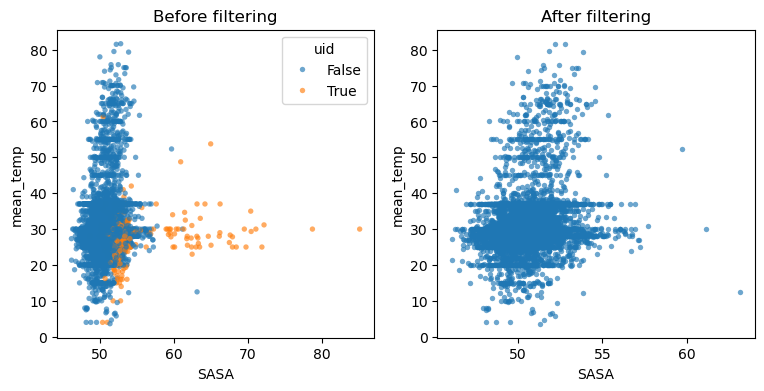

In [55]:
fig = plt.figure(figsize=(9,4))
ax = fig.add_subplot(1,2,1)
sns.scatterplot(data=metrics_df, x='SASA', y='mean_temp', 
                hue=~metrics_df.uid.isin(filtered.uid),
                linewidth=0, alpha=0.65, s=15)
ax.set_title('Before filtering')
ax = fig.add_subplot(1,2,2)
sns.scatterplot(data=filtered, x='SASA', y='mean_temp', 
                # hue=~metrics_df.uid.isin(filtered.uid),
                linewidth=0, alpha=0.65, s=15)
ax.set_title('After filtering')

In [97]:
%%time
tables = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/foldseek/alns/*_aln.txt')
names = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
args = {'header':None, 'sep':'\t', 'names':names}
fs_aln = pd.concat([pd.read_csv(t, **args) for t in tables])
fs_aln

CPU times: user 25.8 s, sys: 1.98 s, total: 27.8 s
Wall time: 52.6 s


,query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits
0,RS_GCF_014333445.1_A_processed.pdb,1ake.pdb,0.117,212,156,0,7,184,1,212,9.236000e-03,38
0,GB_GCA_007050995.1_A_processed.pdb,2cdn_A.pdb,0.438,187,101,0,1,187,6,186,1.423000e-19,697
1,GB_GCA_007050995.1_A_processed.pdb,1ake_A.pdb,0.377,213,115,0,1,185,1,213,3.483000e-15,510
2,GB_GCA_007050995.1_A_processed.pdb,1p4s_A.pdb_MODEL_14_A,0.443,187,100,0,1,187,1,181,3.399000e-14,418
3,GB_GCA_007050995.1_A_processed.pdb,1p4s_A.pdb_MODEL_6_A,0.443,187,100,0,1,187,1,181,1.031000e-13,410
...,...,...,...,...,...,...,...,...,...,...,...,...
17,RS_GCF_010686655.1_A_processed.pdb,1p4s_A.pdb_MODEL_17_A,0.424,185,102,0,2,186,1,178,1.098000e-12,350
18,RS_GCF_010686655.1_A_processed.pdb,1p4s_A.pdb_MODEL_18_A,0.408,185,105,0,2,186,1,178,1.569000e-12,346
19,RS_GCF_010686655.1_A_processed.pdb,1p4s_A.pdb_MODEL_15_A,0.416,185,103,0,2,186,1,178,1.237000e-12,344
20,RS_GCF_010686655.1_A_processed.pdb,1p4s_A.pdb_MODEL_5_A,0.419,184,103,0,4,187,2,179,2.240000e-12,329


In [98]:
fs_aln['genome'] = fs_aln['query'].apply(lambda x: x.split('_A_pro')[0])

In [99]:
%%time
fs_top_scores = fs_aln.groupby('genome').apply(lambda x: x.sort_values('fident', ascending=False).iloc[0, :])

CPU times: user 7.89 s, sys: 386 ms, total: 8.27 s
Wall time: 14 s


In [100]:
fs_top_score_only = fs_top_scores['fident']
fs_top_score_only.reindex(filtered.uid).apply(lambda x: type(x)).value_counts()

fident
<class 'float'>    8951
Name: count, dtype: int64

<Axes: xlabel='fident', ylabel='Count'>

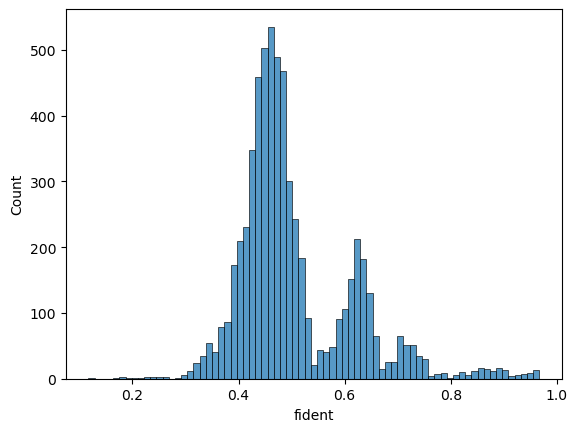

In [101]:
sns.histplot(fs_top_score_only)

<Axes: xlabel='SASA', ylabel='mean_temp'>

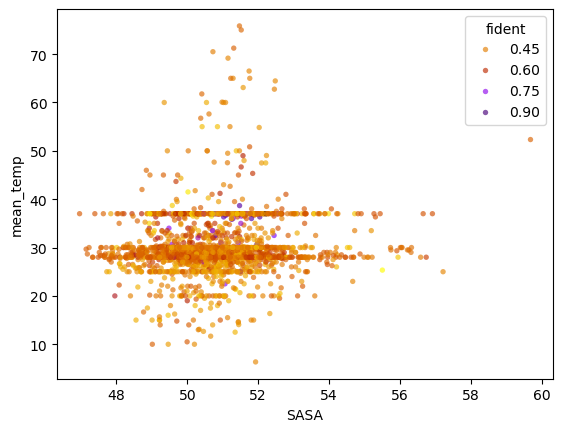

In [104]:
subset = filtered[filtered.uid.isin(fs_top_scores.index)].set_index('uid').query('seq_length < 200')
sns.scatterplot(data=subset, x='SASA', y='mean_temp', 
                hue=fs_top_score_only.reindex(subset.index).fillna(0),
                palette='gnuplot_r',
                linewidth=0, alpha=0.65, s=15)

In [79]:
subset.sort_values('SASA', ascending=False)['SASA']

uid
RS_GCF_014333445.1    61.136284
RS_GCF_000308295.2    57.156636
RS_GCF_000314675.2    56.924088
RS_GCF_001517935.1    55.424462
RS_GCF_000284335.1    55.326429
                        ...    
RS_GCF_000768555.3    47.303867
RS_GCF_000473145.1    47.242150
RS_GCF_000473205.1    47.204952
RS_GCF_000590925.1    47.092493
RS_GCF_001870675.1    46.714405
Name: SASA, Length: 1892, dtype: float64

In [96]:
genome = 'RS_GCF_001517935.1'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

In [87]:
secondary_structure.loc[genome]

secondary_structure    LEEEEELLLLLLHHHHHHHHHHHHLLEEEEHHHHHHHHHHLLLHHH...
Name: RS_GCF_000314675.2, dtype: object

<Axes: xlabel='seq_length', ylabel='Count'>

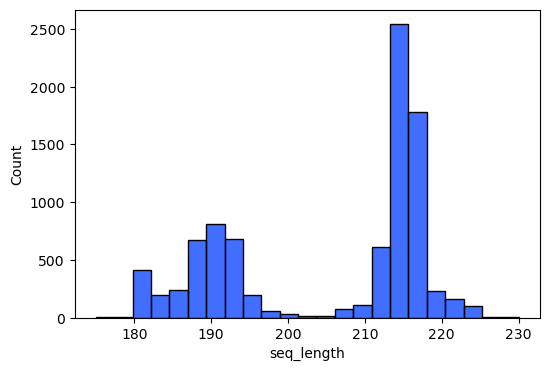

In [139]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(filtered['seq_length'])
# ax.set_xlim(150, 250)

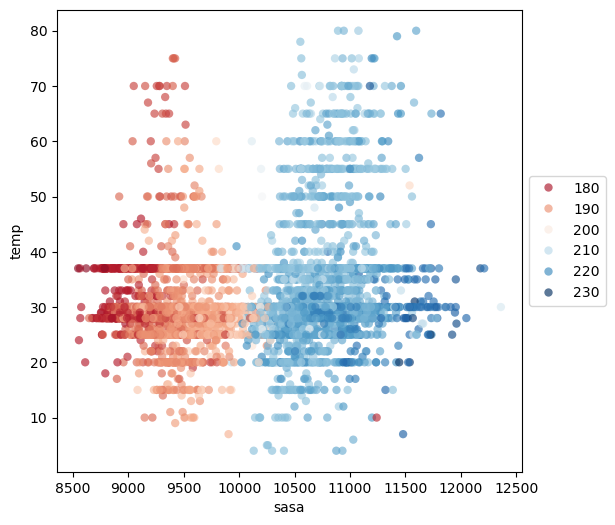

In [140]:
fig, ax = plt.subplots(figsize=(6,6))
# hues = foldseek.set_index('uid')['rep'].apply(lambda rep: rep if rep in top_n.index else 'other')
sns.scatterplot(data=filtered.set_index('uid'), y='temp', x='sasa', linewidth=0, alpha=0.65, 
                hue='seq_length', palette='RdBu')
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.get_legend().remove()
# ax.set_xlim(1000)

In [141]:
genome = 'RS_GCF_000238375.3'
file = f'{genome}_closed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

In [142]:
genome = 'RS_GCF_000238375.3'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

In [143]:
foldseek = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/foldseek/fs_adk_cluster.tsv', sep='\t', 
                       header=None, 
                       names=['rep', 'mem'])
foldseek['uid'] = foldseek['mem'].apply(lambda x: x.split('_closed')[0])

In [144]:
top_n = foldseek['rep'].value_counts().head(2)

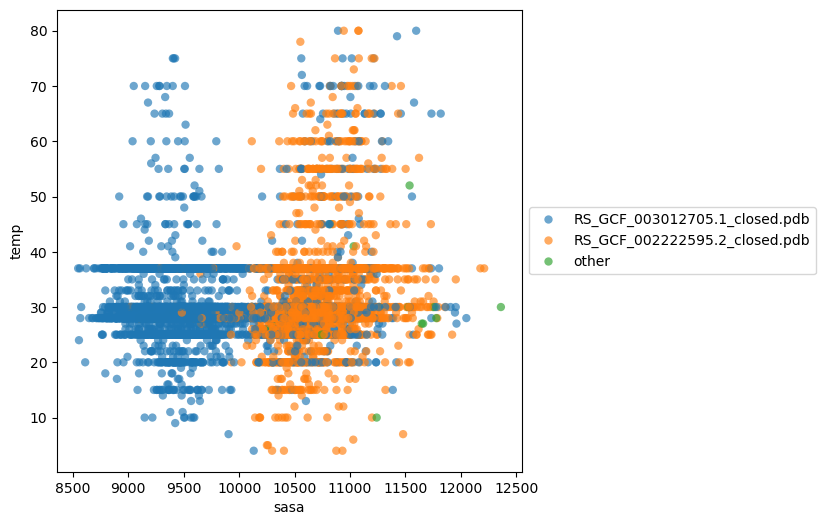

In [145]:
fig, ax = plt.subplots(figsize=(6,6))
hues = foldseek.set_index('uid')['rep'].apply(lambda rep: rep if rep in top_n.index else 'other')
sns.scatterplot(data=filtered.set_index('uid'), y='temp', x='sasa', linewidth=0, alpha=0.65, 
                hue=hues, palette='tab10')
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.get_legend().remove()
# ax.set_xlim(1000)

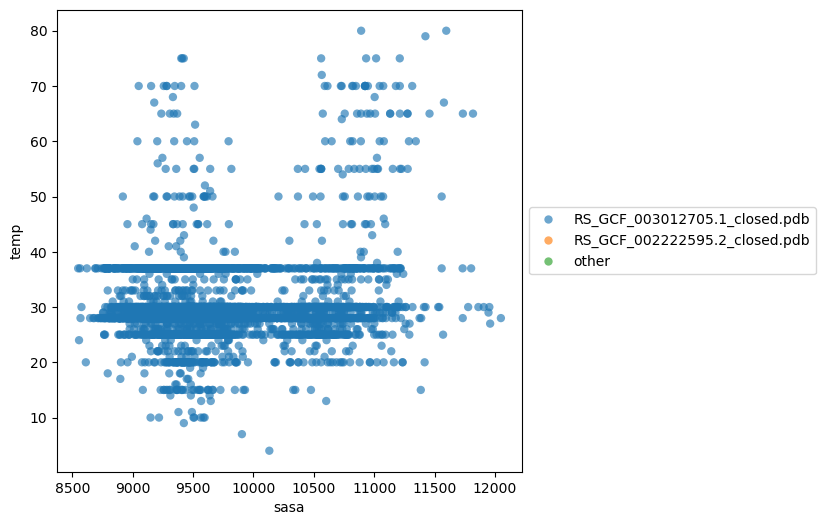

In [146]:
fig, ax = plt.subplots(figsize=(6,6))
hues = foldseek.set_index('uid')['rep'].apply(lambda rep: rep if rep in top_n.index else 'other')
cluster_members = foldseek[foldseek.rep.eq('RS_GCF_003012705.1_closed.pdb')].uid
sns.scatterplot(data=filtered[filtered.uid.isin(cluster_members)].set_index('uid'), y='temp', x='sasa', linewidth=0, alpha=0.65, 
                hue=hues, palette='tab10')
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.get_legend().remove()
# ax.set_xlim(1000)